In [1]:
import numpy as np
import random
import math
import datetime
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import sys
import matplotlib.pyplot as plt
from tqdm import tqdm
from time import time
from datetime import datetime
import tensorflow as tf
import tensorflow_probability as tfp
tfd = tfp.distributions
tfb = tfp.bijectors 

import rioxarray as rxr
import rasterio
from rasterio.plot import plotting_extent
import xarray as xr
import geopandas as gpd
np.set_printoptions(suppress=True)

2024-07-19 13:42:59.771966: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-07-19 13:42:59.772025: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-07-19 13:42:59.772047: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-07-19 13:42:59.778593: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Import data
FH=pd.read_csv("../data/amt_fisher.csv",low_memory=False)
Grass=rxr.open_rasterio("../data/Grass.tif",masked=True)
Wet=rxr.open_rasterio("../data/Wet.tif",masked=True)
Elev=rxr.open_rasterio("../data/Elev.tif",masked=True)
Pop=rxr.open_rasterio("../data/Popden.tif",masked=True)

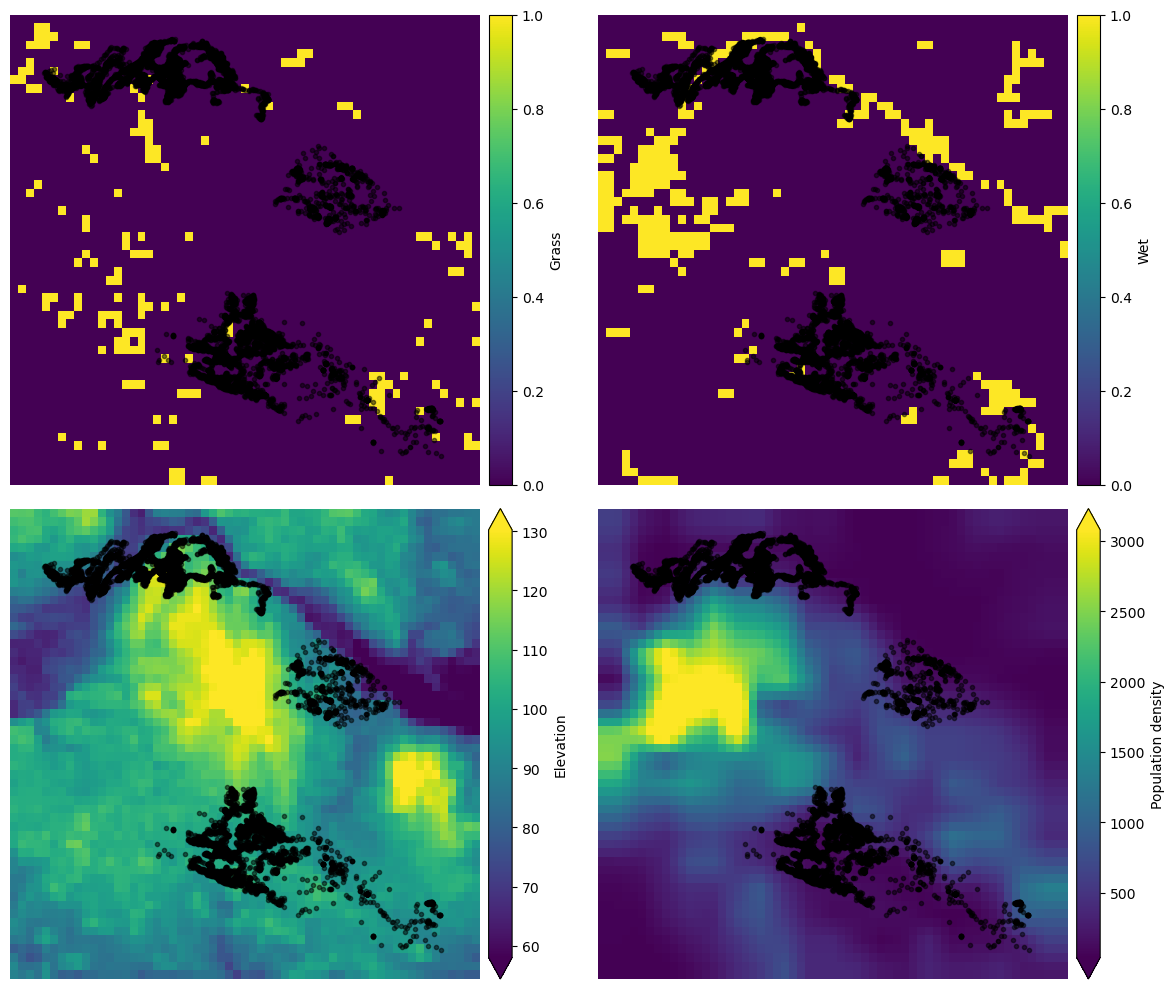

In [3]:
# Visualisation
fig,ax=plt.subplots(2,2,figsize=(12,10))
Grass.plot(robust=True,cmap="viridis",ax=ax[0,0],
       cbar_kwargs={"label":"Grass","pad":0.015,"shrink":1})

ax[0,0].plot(FH["X"],FH["Y"],".",color="black",alpha=0.5)

Wet.plot(robust=True,cmap="viridis",ax=ax[0,1],
       cbar_kwargs={"label":"Wet","pad":0.015,"shrink":1})
ax[0,1].plot(FH["X"],FH["Y"],".",color="black",alpha=0.5)

Elev.plot(robust=True,cmap="viridis",ax=ax[1,0],
       cbar_kwargs={"label":"Elevation","pad":0.015,"shrink":1})
ax[1,0].plot(FH["X"],FH["Y"],".",color="black",alpha=0.5)


Pop.plot(robust=True,cmap="viridis",ax=ax[1,1],
       cbar_kwargs={"label":"Population density","pad":0.015,"shrink":1})
ax[1,1].plot(FH["X"],FH["Y"],".",color="black",alpha=0.5)

ax[0,0].set_axis_off()
ax[0,1].set_axis_off()
ax[1,0].set_axis_off()
ax[1,1].set_axis_off()

ax[0,0].set_title("")
ax[0,1].set_title("")
ax[1,0].set_title("")
ax[1,1].set_title("")

plt.tight_layout()
plt.show()

In [4]:
# Preprocessing raster layers by interpolating NAS
Elev=Elev.rio.interpolate_na(method="nearest")
Pop=Pop.rio.interpolate_na(method="nearest")

In [5]:
# Standardizing the covariates
#Elev=(Elev-np.mean(Elev))/np.std(Elev)
#Pop=(Pop-np.mean(Pop))/np.std(Pop)

# Normalizing the covariates
Elev=Elev/np.max(Elev)
Pop=Pop/np.max(Pop)
#Elev=(Elev-np.min(Elev))/(np.max(Elev)-np.min(Elev))
#Pop=(Pop-np.min(Pop))/(np.max(Pop)-np.min(Pop))

# Stack the covariates together
Cov=np.stack((Elev,Pop,Grass,Wet))
Cov=Cov.squeeze()

In [6]:
class stepSelectionVI(tf.Module):
    def __init__(self, n_covars, cov_tensor, x_ref_min, x_ref_max, move_std=1.0,prior_mean=None, prior_std=None,n_gh_points=4,n_vi_samples=4):
               
      
        self.n_covars = n_covars
        self.cov_tensor = cov_tensor
        self.n_gh_points = n_gh_points
        self.n_vi_samples = n_vi_samples
        
        self.x_ref_min = x_ref_min
        self.x_ref_max = x_ref_max

        # set up the points for Gauss-Hermite quadrature
        xi, wi = np.polynomial.hermite.hermgauss(n_gh_points)

        ghx,ghy = np.meshgrid(xi,xi)
        self.gh_grid = tf.convert_to_tensor(np.stack([ghx,ghy],axis=2).astype(np.float32)) 

        ghx,ghy = np.meshgrid(wi,wi)
        
        self.grid_gh_weights = tf.convert_to_tensor(ghy,dtype=tf.float32)
        self.gh_weights = tf.convert_to_tensor(wi,dtype=tf.float32)
        self.move_std = tfp.util.TransformedVariable(move_std,tfp.bijectors.Softplus(),dtype=tf.float32)
        self.beta_mean = tf.Variable(np.zeros((n_covars)),dtype=tf.float32)
        self.beta_std = tfp.util.TransformedVariable([np.ones(n_covars,dtype=np.float32)],tfp.bijectors.Softplus(),dtype=tf.float32)
        self.variational_posterior = tfp.distributions.MultivariateNormalDiag(loc = self.beta_mean, scale_diag=self.beta_std)
        
        
        # set default prior to be N(0,10)
        if prior_mean is None:
            prior_mean = np.zeros((n_covars))
        if prior_std is None:
            prior_std = 10.0*np.ones((n_covars))
        prior_mean = tf.constant(prior_mean,dtype=tf.float32)
        prior_std = tf.constant(prior_std,dtype=tf.float32)
        self.prior = tfp.distributions.MultivariateNormalDiag(loc=prior_mean, scale_diag=prior_std)

    @tf.function
    def variational_loss(self, start_points_batch,end_points_batch,step_times_batch,kl_weight = 1.0):
        beta_samples = tf.random.normal((self.n_vi_samples,self.n_covars,1),dtype=tf.float32)
        beta_samples = (tf.expand_dims(self.beta_mean,axis=-1) + tf.linalg.matmul(self.beta_std,beta_samples))[...,0]
        
        elogp = tf.reduce_mean(self.log_likelhood(beta_samples,start_points_batch,end_points_batch,step_times_batch))
        penalty = kl_weight * tfp.distributions.kl_divergence(self.variational_posterior,self.prior)

        return -elogp+penalty
    
    
    # fast vectorised tf code
    @tf.function
    def log_likelhood(self, beta_params,start_points,end_points,step_times):
        # calculate the covariates at the step end locations using tensorflow probability
        cov_xy_end = tfp.math.batch_interp_regular_nd_grid(end_points, self.x_ref_min, self.x_ref_max, self.cov_tensor, axis=-3)
        # calculate the rsf
        rsf_points_end = tf.exp(tf.math.reduce_sum(tf.multiply(tf.expand_dims(cov_xy_end,0),tf.expand_dims(beta_params,1)),axis=-1))
        
        sigmas = tf.math.sqrt(step_times*0.5)*self.move_std
        

        def fn(input_locations):
            
            ## shapes needs to broadcast with (num_steps,ghx points, ghy points, 2)
            half_sigma = tf.reshape(sigmas,(-1,1,1,1))
            means = tf.reshape(input_locations,(-1,1,1,2))

            # shape is numvisamples, num steps, ghx,ghy, 1xnc matrix of coefficients
            betas = tf.reshape(beta_params,(-1,1,1,1,1,self.n_covars))
            gh_points = means+(2**0.5)*half_sigma*self.gh_grid
            cov_gh_points  = tfp.math.batch_interp_regular_nd_grid(gh_points, self.x_ref_min, self.x_ref_max, self.cov_tensor, axis=-3)
            # need to add a dimension at the start to broadcast with num samples
            cov_gh_points = tf.expand_dims(tf.expand_dims(cov_gh_points,-1),0) 

            rsf =tf.exp(tf.matmul(betas,cov_gh_points)[...,0,0])

            # rsf is now dimension (numvisamples, numsteps, ghx, ghy)
            # multiply by the weights and sum to approximate the inner integral
            ysum = tf.math.reduce_sum(rsf*self.grid_gh_weights/(np.pi**0.5),axis=2)
            # multiply by the weights and sum to approximate the outer integral
            xsum = tf.math.reduce_sum(ysum*self.gh_weights/(np.pi**0.5),axis=2)
            return xsum

        half_sigma = tf.reshape(sigmas,(1,1,-1,1))


        # reshape to be ghx, ghx, num steps, 2
        mean_c = tf.reshape(0.5*(start_points+end_points),(1,1,-1,2))


        mid_points = mean_c + half_sigma*tf.expand_dims(self.gh_grid,2)

        inv_int_z = tf.math.pow(tf.map_fn(fn,tf.reshape(mid_points,(self.n_gh_points*self.n_gh_points,-1,2)),parallel_iterations=1),-1)


        inv_int_z = tf.reshape(inv_int_z,(self.n_gh_points,self.n_gh_points,tf.shape(inv_int_z)[1],tf.shape(inv_int_z)[2]))

        # inv_int_z is now shape (ghx,ghy,num vi samples, num steps)
        ysum = tf.math.reduce_sum(inv_int_z*tf.reshape(self.grid_gh_weights,(self.n_gh_points,self.n_gh_points,1,1))/(np.pi**0.5),axis=0)
        xsum = tf.math.reduce_sum(ysum*tf.reshape(self.gh_weights,(self.n_gh_points,1,1))/(np.pi**0.5),axis=0)


        step_log_prob = tfp.distributions.Independent(tfp.distributions.Normal(loc=start_points,scale=(2**0.5)*sigmas),reinterpreted_batch_ndims=1).log_prob(end_points)

        log_prob = tf.math.log(rsf_points_end) + tf.math.log(xsum) + step_log_prob
        return -tf.math.reduce_sum(log_prob,axis=-1)

In [7]:
# Convert date to recognized format
def make_Date(df):
    return datetime.strptime(df["Date"],"%Y-%m-%d %H:%M:%S")
FH["Timestamp"]=FH.apply(make_Date,axis=1)
FH["Date"]=FH["Timestamp"]

# Filter only lupe as in the paper
FH=FH[FH["name"]=="Lupe"]

In [8]:
# preprocessing steps convert to tensors and handle the change of ID, start/end points and time between fixes


# Convert time to hours
secs =(pd.to_datetime(FH["Timestamp"])- datetime.strptime("1970-01-01 00:00:00","%Y-%m-%d %H:%M:%S")).dt.total_seconds().values

T = (secs/60)

XY=FH[["X","Y"]].values
 
ID = FH["id"].values

start_points = []
end_points = []
step_times = []

for i in np.unique(ID):
    cxy = XY[ID==i]
    cdt = T[ID==i]
    cdt=np.diff(cdt)
    if cdt.shape[0]<2:
        continue
    sp = cxy[:-1]
    ep = cxy[1:]
    dt = np.atleast_2d(cdt).T
    sp = sp[dt[:,0]<=2.33]
    ep = ep[dt[:,0]<=2.33]
    dt = dt[dt[:,0]<=2.33]
    sp = sp[dt[:,0]>1.66]
    ep = ep[dt[:,0]>1.66]
    dt = dt[dt[:,0]>1.66]
    start_points.append(sp)
    end_points.append(ep)
    step_times.append(dt)

indexes = np.arange(np.vstack(start_points).shape[0])
np.random.shuffle(indexes)
start_points = tf.convert_to_tensor(np.vstack(start_points)[indexes],dtype=tf.float32)
end_points = tf.convert_to_tensor(np.vstack(end_points)[indexes],dtype=tf.float32)
step_times = tf.convert_to_tensor(np.vstack(step_times)[indexes],dtype=tf.float32)
cov_tensor = tf.transpose(tf.convert_to_tensor(Cov,dtype=tf.float32),[1,2,0])
xlim = Elev.rio.bounds()
x_ref_min= [xlim[0],xlim[1]]
x_ref_max= [xlim[2],xlim[3]]

2024-07-19 13:43:22.618082: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13775 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0001:00:00.0, compute capability: 7.5


In [9]:
# How many observations 
print(len(step_times.numpy()))
print(len(start_points.numpy()))
print(len(end_points.numpy()))

1671
1671
1671


In [10]:
# Create the instance of the model and set up the training
ssf = stepSelectionVI(4,cov_tensor,x_ref_min,x_ref_max,move_std=17.0,n_gh_points=8,n_vi_samples=64)

2024-07-19 13:43:28.520809: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


In [11]:
## set up the dataset and optimizer
batch_size=256
train_dataset = tf.data.Dataset.from_tensor_slices((start_points, end_points, step_times))
train_dataset = train_dataset.shuffle(buffer_size=64).batch(batch_size,drop_remainder=True)
kl_weight = batch_size/start_points.shape[0]
optimizer=tf.keras.optimizers.SGD(learning_rate=0.005, clipvalue=1.0)

In [12]:
# Get the trainable variable from the model
Trainable_vars=tf.Variable(initial_value=[[0.3,-0.1,0.1,0.5]], trainable=True,dtype=tf.float32)

epochs=range(1000)
# Optimization
for epoch in epochs:
    for data_batch in tqdm(train_dataset):
        with tf.GradientTape() as tape:
            tape.watch(Trainable_vars)
            loss = ssf.log_likelhood(Trainable_vars,*data_batch)
        gradients=tape.gradient(loss,[Trainable_vars])
        optimizer.apply_gradients(zip(gradients, [Trainable_vars]))

  0%|          | 0/6 [00:00<?, ?it/s]2024-07-19 13:43:40.308668: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x555dc2c62900 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-07-19 13:43:40.308705: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2024-07-19 13:43:40.317979: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8700
2024-07-19 13:43:40.372372: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
100%|██████████| 6/6 [00:03<00:00,  1.82it/s]


In [13]:
# Print trainable variables
Trainable_vars.numpy()

array([[ 0.62163407,  0.95002574, -1.9458164 ,  0.2637674 ]],
      dtype=float32)